In [1]:
#!pip install -q pytorch-metric-learning

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

import torchvision
from pytorch_metric_learning.losses import NTXentLoss

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


from sklearn.manifold import TSNE
import seaborn as sns
import pandas as pd
import os

In [7]:
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

EPOCHS = 5000
BATCH_SIZE = 128
LEARNING_RATE = 1e-4
TEMP = 0.1
SAVE_FREQ = 100
MODEL_SAVE_DIR = "models/"

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

In [8]:
train_transformation = torchvision.transforms.Compose([
                                        torchvision.transforms.ToTensor()])

test_transformation = torchvision.transforms.Compose([
                                        torchvision.transforms.ToTensor(), 
                                        torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])


simclr_aug = torchvision.transforms.Compose([
    torchvision.transforms.RandomResizedCrop(32, scale=(0.2, 1.0), ratio=(3/4, 4/3)),
    torchvision.transforms.RandomHorizontalFlip(p=0.5),
    torchvision.transforms.RandomApply([
        torchvision.transforms.ColorJitter(brightness=0.8, contrast=0.8, saturation=0.8, hue=0.2)], p=0.8),
    torchvision.transforms.RandomGrayscale(p=0.2),
    torchvision.transforms.RandomApply([
        torchvision.transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))], p=0.5),
    #torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])


class TwoViews():
    def __init__(self, base_transform):
        self.base_transform = base_transform

    def __call__(self, x):
        return self.base_transform(x), self.base_transform(x)


def initialize_weights(model):
    for m in model.modules():

        if isinstance(m, torch.nn.Conv2d):
            torch.nn.init.kaiming_normal_(
                m.weight,
                mode='fan_out',
                nonlinearity='relu'
            )
            if m.bias is not None:
                torch.nn.init.zeros_(m.bias)

        elif isinstance(m, torch.nn.BatchNorm2d):
            torch.nn.init.ones_(m.weight)
            torch.nn.init.zeros_(m.bias)

        elif isinstance(m, torch.nn.Linear):
            torch.nn.init.kaiming_normal_(
                m.weight,
                mode='fan_out',
                nonlinearity='relu'
            )
            if m.bias is not None:
                torch.nn.init.zeros_(m.bias)

In [9]:
class CNNModel(torch.nn.Module):
    def __init__(self, in_channels):
        super().__init__()

        self.conv_1 = torch.nn.Conv2d(in_channels=in_channels, out_channels=16, kernel_size=2, stride=2)
        self.bn_1 = torch.nn.BatchNorm2d(16)
        self.conv_2 = torch.nn.Conv2d(in_channels=16, out_channels=32, kernel_size=2, stride=2)
        self.bn_2 = torch.nn.BatchNorm2d(32)
        self.conv_3 = torch.nn.Conv2d(in_channels=32, out_channels=32, kernel_size=2)
        self.bn_3 = torch.nn.BatchNorm2d(32)

        self.act_func = torch.nn.ReLU()

        # projection head
        self.projection_enc = torch.nn.Linear(32 * 7 * 7, 32)

    def encode(self, x):
        """Backbone features (pre-projection). Use this for downstream tasks / eval."""
        x = self.act_func(self.bn_1(self.conv_1(x)))
        x = self.act_func(self.bn_2(self.conv_2(x)))
        x = self.act_func(self.bn_3(self.conv_3(x)))
        return x

    def forward(self, x):
        """Encode a single (already-augmented) view and project it."""
        features = self.encode(x)
        return self.projection_enc(features.reshape(-1, 32 * 7 * 7))

In [10]:
model = CNNModel(in_channels=3)
model.apply(initialize_weights)
model = model.to(device)

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transformation)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)

augment_cls = TwoViews(simclr_aug)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = NTXentLoss(temperature=TEMP)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=500, gamma=0.9)

In [7]:
model.train()
loss_history = []

for epoch in range(EPOCHS):
    epoch_losses = []

    for data, _ in trainloader:
        optimizer.zero_grad()

        view_1, view_2 = augment_cls(data)

        view_1 = view_1.to(device)
        view_2 = view_2.to(device)

        # project each view independently
        z1 = model(view_1)
        z2 = model(view_2)

        embeddings = torch.cat((z1, z2), dim=0)
        # positives share the same label: view_1[i] and view_2[i]
        indices = torch.arange(z1.size(0), device=z1.device)
        labels = torch.cat((indices, indices), dim=0)

        loss = criterion(embeddings, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        epoch_losses.append(loss.item())

    scheduler.step()
    mean_loss = sum(epoch_losses) / len(epoch_losses)
    loss_history.append(mean_loss)
    print(f"Epoch: {epoch+1}, mean loss: {mean_loss:.4f}")
    if epoch%SAVE_FREQ == 0:
        torch.save(model.state_dict(), os.path.join(MODEL_SAVE_DIR, f"model_{epoch}.pt"))

Epoch: 1, mean loss: 4.7942
Epoch: 2, mean loss: 4.4524
Epoch: 3, mean loss: 4.2264
Epoch: 4, mean loss: 4.0188
Epoch: 5, mean loss: 4.0497
Epoch: 6, mean loss: 3.8686
Epoch: 7, mean loss: 3.7362
Epoch: 8, mean loss: 3.5721
Epoch: 9, mean loss: 3.6050
Epoch: 10, mean loss: 3.5986
Epoch: 11, mean loss: 3.4998
Epoch: 12, mean loss: 3.3909
Epoch: 13, mean loss: 3.4856
Epoch: 14, mean loss: 3.4743
Epoch: 15, mean loss: 3.2362
Epoch: 16, mean loss: 3.3284
Epoch: 17, mean loss: 3.3175
Epoch: 18, mean loss: 3.2946
Epoch: 19, mean loss: 3.1279
Epoch: 20, mean loss: 3.1589
Epoch: 21, mean loss: 3.1435
Epoch: 22, mean loss: 3.0532
Epoch: 23, mean loss: 3.2049
Epoch: 24, mean loss: 3.1180
Epoch: 25, mean loss: 3.0530
Epoch: 26, mean loss: 3.0800
Epoch: 27, mean loss: 2.9436
Epoch: 28, mean loss: 2.9470
Epoch: 29, mean loss: 3.0108
Epoch: 30, mean loss: 2.9322
Epoch: 31, mean loss: 2.9520
Epoch: 32, mean loss: 2.8856
Epoch: 33, mean loss: 2.9310
Epoch: 34, mean loss: 2.8466
Epoch: 35, mean loss: 2

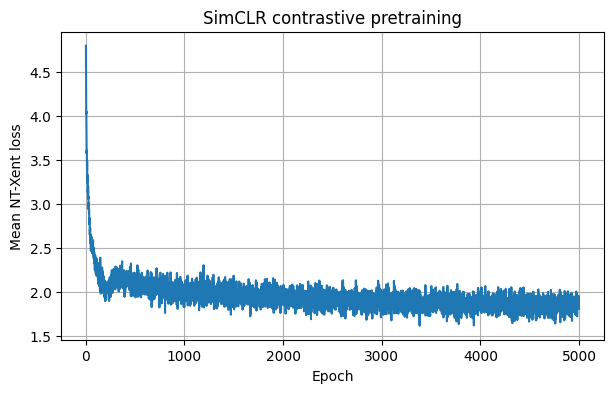

In [17]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(loss_history) + 1), loss_history)#, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Mean NT-Xent loss")
plt.title("SimCLR contrastive pretraining")
plt.grid(True)
plt.show()

In [12]:
def label_points(x, y, val, ax):
    a = pd.concat({"x":x, "y":y, "val":val}, axis=1)
    for i, point in a.iterrows():
        ax.text(point["x"]+0.02, point["y"], str(int(point["val"])))

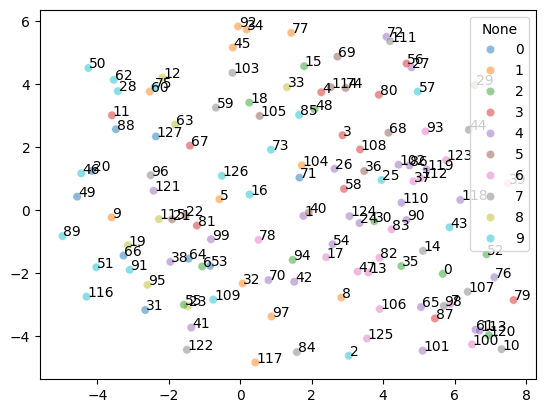

In [10]:
sample, label = next(iter(trainloader))

emb_h = model.encode(sample.to(device))
emb_h = emb_h.cpu().detach().numpy()
emb_h = emb_h.reshape(-1, 32*7*7)

emb_h_2D = TSNE(n_components=2, learning_rate="auto", init="random").fit_transform(emb_h)

ax = sns.scatterplot(x=emb_h_2D[:, 0], y=emb_h_2D[:, 1], hue=label, alpha=0.5, palette="tab10")
# add numbers to the samples
annotations = list(range(len(emb_h_2D[:, 0])))
label_points(pd.Series(emb_h_2D[:, 0]), pd.Series(emb_h_2D[:, 1]), pd.Series(annotations), ax)

In [13]:
def similar_emb(a, b, eps=1e-8):
    a_n, b_n = np.linalg.norm(a, axis=1)[:, None], np.linalg.norm(b, axis=1)[:, None]
    a_norm = a/np.maximum(a_n, eps*np.ones_like(a_n))
    b_norm = b/np.maximum(b_n, eps*np.ones_like(b_n))

    sim_emb = np.matmul(a_norm, b_norm.T)

    return sim_emb
    

In [12]:
similarity = similar_emb(emb_h, emb_h)
max_indices = np.argsort(similarity, axis=1)[:, -3:][:, ::-1]

In [13]:
print(max_indices)

[[  0   7 113]
 [  1  33  17]
 [  2 125 112]
 [  3  30 119]
 [  4  48  74]
 [  5   9 126]
 [  6  55  64]
 [  7  61 113]
 [  8 106  82]
 [  9   5 126]
 [ 10  61 120]
 [ 11  88  28]
 [ 12  75  28]
 [ 13  82 100]
 [ 14  65  98]
 [ 15   3  45]
 [ 16 126   5]
 [ 17 100  83]
 [ 18  11 105]
 [ 19 115  49]
 [ 20  46  60]
 [ 21 115  81]
 [ 22 115  81]
 [ 23  55  19]
 [ 24  30  82]
 [ 25  36  37]
 [ 26   3 108]
 [ 27  56 111]
 [ 28  11  62]
 [ 29 111   3]
 [ 30   7   0]
 [ 31  19  91]
 [ 32  55  19]
 [ 33 111   4]
 [ 34  92  45]
 [ 35  82  13]
 [ 36  25  69]
 [ 37 107 112]
 [ 38  22  91]
 [ 39 106  22]
 [ 40  42   1]
 [ 41  55  23]
 [ 42  55  17]
 [ 43  35   0]
 [ 44  25 108]
 [ 45  75  60]
 [ 46  20  49]
 [ 47 100  13]
 [ 48   4  33]
 [ 49  19  46]
 [ 50 126  62]
 [ 51  91  88]
 [ 52  79 107]
 [ 53  31  64]
 [ 54  17  13]
 [ 55  23  41]
 [ 56 111  27]
 [ 57  27  72]
 [ 58  25   3]
 [ 59  12  46]
 [ 60  75  63]
 [ 61 113 120]
 [ 62  28  60]
 [ 63  60  75]
 [ 64  19   6]
 [ 65  98  87]
 [ 66  91 

In [14]:
sample = sample.permute(0, 2, 3, 1)
print(sample.shape)

torch.Size([128, 32, 32, 3])


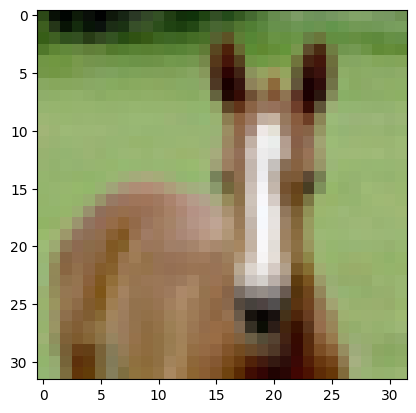

In [23]:
plt.imshow(sample[10])

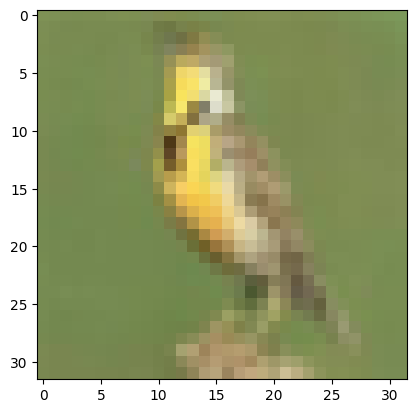

In [25]:
plt.imshow(sample[120])

## Inference

In [28]:
def get_acc_on_emb(model, dataloader):

    test_emb_X = None
    test_y = None

    with torch.no_grad():
        for sample, label in dataloader:

            emb_h = model.encode(sample.to(device))
            emb_h = emb_h.cpu().detach().numpy()
            emb_h = emb_h.reshape(-1, 32*7*7)

            if test_emb_X is None:
                test_emb_X = emb_h
                test_y = label.numpy()
            else:
                test_emb_X = np.append(test_emb_X, emb_h, axis=0)
                test_y = np.append(test_y, label, axis=0)




    knn = KNeighborsClassifier(
        n_neighbors=5,
        metric="cosine"
    )

    knn.fit(test_emb_X, test_y)

    y_pred = knn.predict(test_emb_X)

    print(f"Accuracy: {accuracy_score(test_y, y_pred) * 100:.2f}%")

In [ ]:
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transformation)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=True)


In [31]:
model = CNNModel(in_channels=3)
model.apply(initialize_weights)
model = model.to(device)
model.eval()
print("Before training:")
get_acc_on_emb(model, testloader)

Before training:
Accuracy: 50.97%


In [32]:
load_epoch = 4900
model = CNNModel(in_channels=3)
model.load_state_dict(torch.load(os.path.join(MODEL_SAVE_DIR, f"model_{load_epoch}.pt")))
model = model.to(device)
model.eval()
print("After training:")
get_acc_on_emb(model, testloader)



After training:
Accuracy: 64.54%


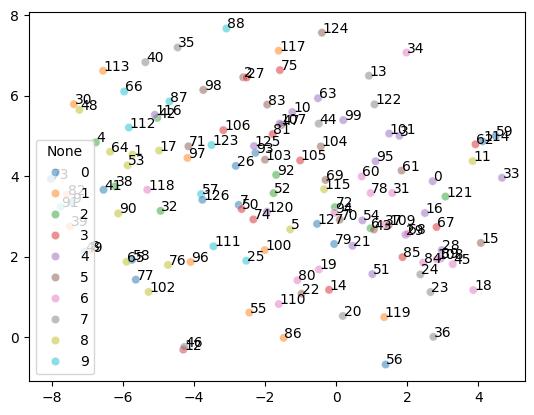

In [24]:
sample, label = next(iter(testloader))

emb_h = model.encode(sample.to(device))
emb_h = emb_h.cpu().detach().numpy()
emb_h = emb_h.reshape(-1, 32*7*7)

emb_h_2D = TSNE(n_components=2, learning_rate="auto", init="random").fit_transform(emb_h)

ax = sns.scatterplot(x=emb_h_2D[:, 0], y=emb_h_2D[:, 1], hue=label, alpha=0.5, palette="tab10")
# add numbers to the samples
annotations = list(range(len(emb_h_2D[:, 0])))
label_points(pd.Series(emb_h_2D[:, 0]), pd.Series(emb_h_2D[:, 1]), pd.Series(annotations), ax)